In [3]:
# Preparar datos para el modelo Approximate Bayesian Computation (ABC)
import numpy as np
import pandas as pd
import statsmodels.api as sm
import scipy.stats as stats
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
from funciones import (
    fourier_mensual,
    dividir_train_test,
    parametros_ubicaciones,
    comprobar_dimensiones_ubic
)

In [214]:
def flujo_previo_ABC(region, ruta_datos_precipitacion = 'tablas_precipitaciones.parquet', print_comprobacion_dimensiones = False):
    # Cargar datos de precipitaciones CHIRPS
    datos_precipitacion = pd.read_parquet(ruta_datos_precipitacion)

    # Filtrar datos para cada región
    datos_region = preparar_datos_region(datos_precipitacion, region)
    
    # Fecha corte para training
    fecha_corte_2018 = pd.to_datetime('2018-12-31')

    # Determinar parámetros relacionados con las ubicaciones
    ubic, nsites, dist_mat = parametros_ubicaciones(datos_region)

    # Separar en training y testing
    datos_region_train, datos_region_test, m_training = dividir_train_test(datos_region, ubic, nsites, fecha_corte_2018)

    # Determinar parámetros relacionados con las ubicaciones (training y testing)
    ubic_training, nsites_training, dist_mat_training = parametros_ubicaciones(datos_region_train)

    # Constructores para estandarizar información
    poly_region, scaler_region = preprocesamiento_escalar_datos(datos_region_train)

    # Modelo regresión lineal
    model_OLS_region = calibrar_modelo_glm(datos_region_train, print_summary = True)

    datos_region_train = GLM_predicciones_residuos_train(datos_region_train, model_OLS_region)
    datos_region_test = GLM_predicciones_residuos_test(datos_region_test, poly_region, scaler_region, model_OLS_region)

    ## Datos de entrenamiento (reales)
    datos_region_train = datos_region_train.sort_values(['lat','lon','date'],ascending=[False,True,True])
    datos_region_train_pivot = datos_region_train.pivot(index='date', columns=['lat','lon'], values='exp_residuos')

    ## Datos para prueba (reales)
    datos_region_test = datos_region_test.sort_values(['lat','lon','date'],ascending=[False,True,True])

    if print_comprobacion_dimensiones:
        print(comprobar_dimensiones_ubic(ubic_training, datos_region_train_pivot))

    return {
        "ubic": ubic,
        "nsites": nsites,
        "dist_mat": dist_mat,
        "train": datos_region_train,
        "train_pivot": datos_region_train_pivot,
        "test": datos_region_test,
        "OLS": model_OLS_region,
        "ubic_training": ubic_training,
        "nsites_training": nsites_training,
        "dist_mat_training": dist_mat_training,
        "m_training": m_training,
    }

In [215]:
data = flujo_previo_ABC(region = "Los Santos", print_comprobacion_dimensiones = False)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 chirps   No. Observations:                 8208
Model:                            GLM   Df Residuals:                     8192
Model Family:                   Gamma   Df Model:                           15
Link Function:                    log   Scale:                         0.27710
Method:                          IRLS   Log-Likelihood:                -45276.
Date:                lun, 15 jun 2026   Deviance:                       1902.2
Time:                        15:00:11   Pearson chi2:                 2.27e+03
No. Iterations:                    18   Pseudo R-squ. (CS):             0.9583
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.7771      0.022    169.744      0.0

In [216]:
print(data['train'].head())

       lat   lon year_month      chirps  elevation       date month  year  \
13800  9.9 -84.1    2000-01   17.518916     1187.0 2000-01-01     1  2000   
13801  9.9 -84.1    2000-02    7.998379     1187.0 2000-02-01     2  2000   
13802  9.9 -84.1    2000-03   11.473929     1187.0 2000-03-01     3  2000   
13803  9.9 -84.1    2000-04   52.564947     1187.0 2000-04-01     4  2000   
13804  9.9 -84.1    2000-05  306.690725     1187.0 2000-05-01     5  2000   

       sin_1  cos_1  sin_2  cos_2     ENSO      Y_plus      Y_pred  \
13800  0.500  0.866  0.866    0.5  La Niña   18.518916   37.734467   
13801  0.866  0.500  0.866   -0.5  La Niña    8.998379   14.455007   
13802  1.000  0.000  0.000   -1.0  La Niña   12.473929   29.156876   
13803  0.866 -0.500 -0.866   -0.5  La Niña   53.564947   80.604789   
13804  0.500 -0.866 -0.866    0.5  La Niña  307.690725  300.135429   

       exp_residuos  
13800      0.490769  
13801      0.622509  
13802      0.427821  
13803      0.664538  
13804 

In [118]:
print(data['OLS'].summary())

                            OLS Regression Results                            
Dep. Variable:                 chirps   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     5100.
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        08:37:37   Log-Likelihood:                -6329.2
No. Observations:                8208   AIC:                         1.268e+04
Df Residuals:                    8199   BIC:                         1.274e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.8226      0.009    554.615      0.0

In [217]:
df_plot = (
    data['train']
    .groupby('date')
    .agg({
        'chirps': 'mean',
        'ENSO': 'first'  # ENSO es global, esto está bien
    })
    .reset_index()
    .sort_values('date')
)

df_plot['grupo'] = (df_plot['ENSO'] != df_plot['ENSO'].shift()).cumsum()

bloques = df_plot.groupby('grupo').agg(
    inicio=('date', 'min'),
    fin=('date', 'max'),
    ENSO=('ENSO', 'first')
).reset_index()

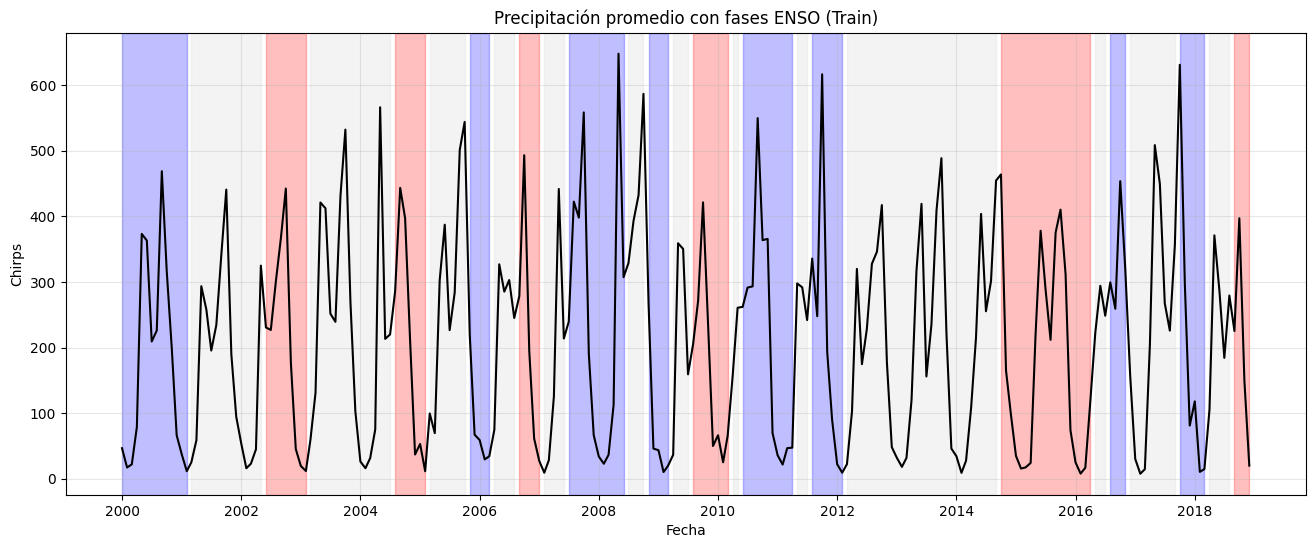

In [218]:
import matplotlib.pyplot as plt

colores = {
    'El Niño': 'red',
    'La Niña': 'blue',
    'Neutral': 'lightgray'
}

plt.figure(figsize=(16,6))

# 🔵 Fondo ENSO
for _, row in bloques.iterrows():
    plt.axvspan(row['inicio'], row['fin'],
                color=colores[row['ENSO']], alpha=0.25)

# ⚫ Línea de precipitación
plt.plot(df_plot['date'], df_plot['chirps'], color='black', linewidth=1.5)

plt.title("Precipitación promedio con fases ENSO (Train)")
plt.xlabel("Fecha")
plt.ylabel("Chirps")

plt.grid(alpha=0.3)
plt.show()

In [222]:
import matplotlib.pyplot as plt

def plot_real_vs_pred(train, model_GLM):
    Y = train['chirps']
    Y_pred = train["Y_pred"] - 1

    plt.figure(figsize=(6,6))
    plt.scatter(Y_pred, Y, alpha=0.6)

    # Identidad
    min_val = min(Y.min(), Y_pred.min())
    max_val = max(Y.max(), Y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')

    plt.xlabel("Predicción")
    plt.ylabel("Observado")
    plt.title("Real vs Predicción (GLM Gamma)")
    plt.grid(True)

    plt.show()

    # Deviance
    plt.scatter(model_GLM.fittedvalues, model_GLM.resid_deviance, alpha=0.3)
    plt.axhline(0, linestyle='--', color='red')
    plt.xlabel("Fitted")
    plt.ylabel("Residuals (Deviance)")

    plt.show()

def plot_modelo_glm_ubic(datos, ubic, max_plots=10):
    count = 0

    for _, row in ubic.iterrows():
        lat, lon = row['lat'], row['lon']
        
        a = datos[(datos['lat'] == lat) & (datos['lon'] == lon)].copy()

        # Crear figura con 3 subplots
        fig, axes = plt.subplots(2, 1, figsize=(10, 8))

        # 1. Serie temporal
        axes[0].plot(a["date"], a["chirps"], label="chirps")
        axes[0].plot(a["date"], a["Y_pred"] - 1, label="Y_pred")
        axes[0].set_title(f"Lat={lat}, Lon={lon}")
        axes[0].set_ylabel("Precipitaciones")
        axes[0].legend()
        axes[0].grid()

        # 2. RatioY
        axes[1].plot(a["date"], a["exp_residuos"], label="exp_residuos")
        axes[1].axhline(0, linestyle='--')
        axes[1].set_ylabel("exp_residuos")
        axes[1].set_xlabel("Fecha")
        axes[1].grid()

        plt.tight_layout()
        plt.show()
    
        count += 1
        if count >= max_plots:
            break

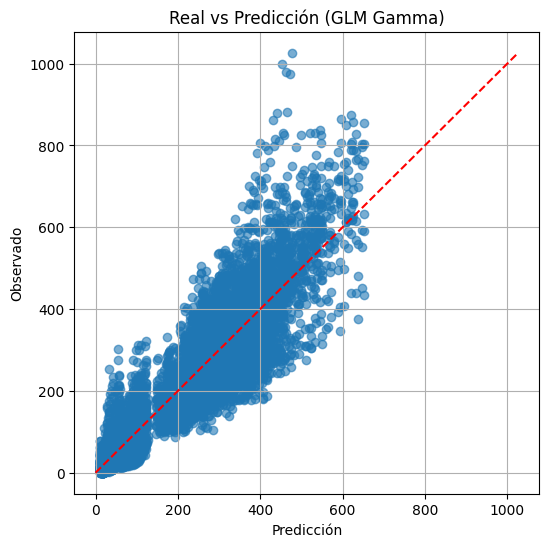

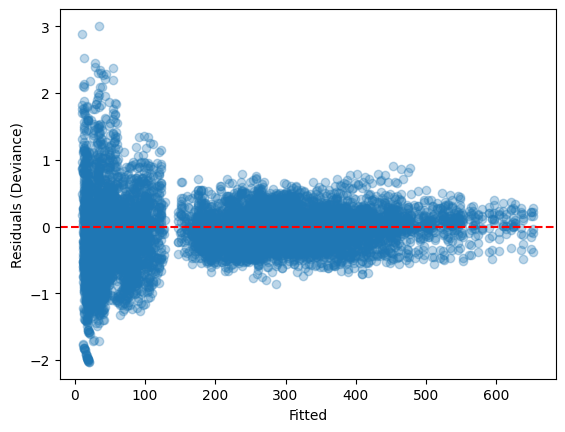

In [225]:
plot_real_vs_pred(data['train'], data['OLS'])

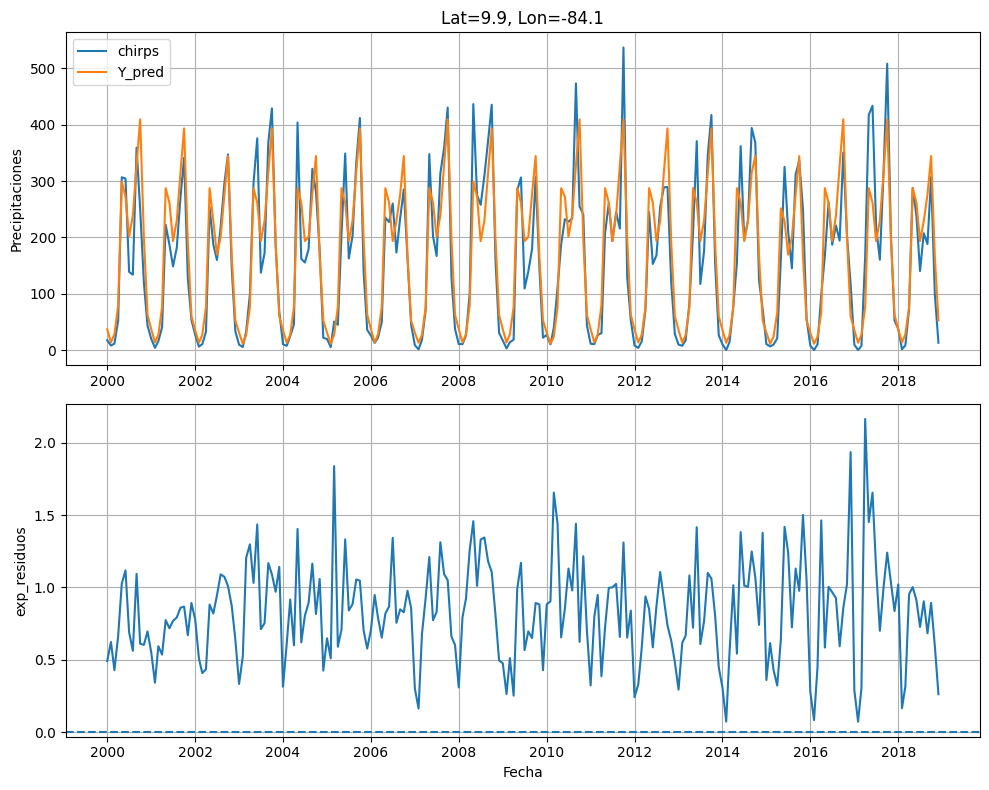

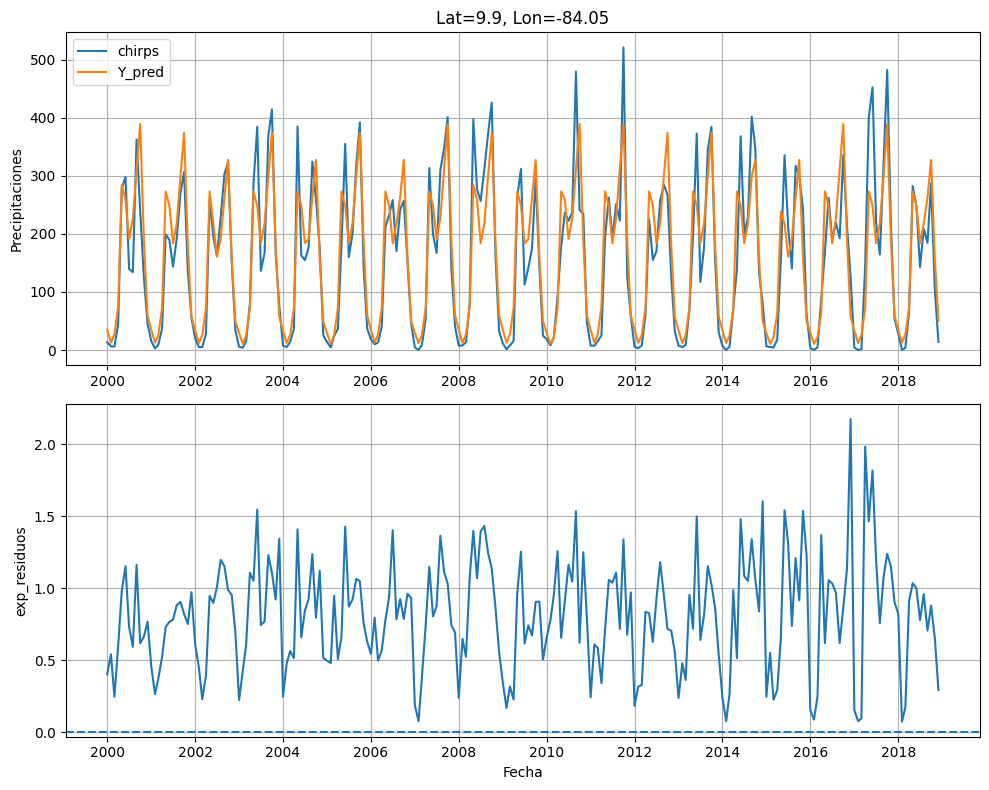

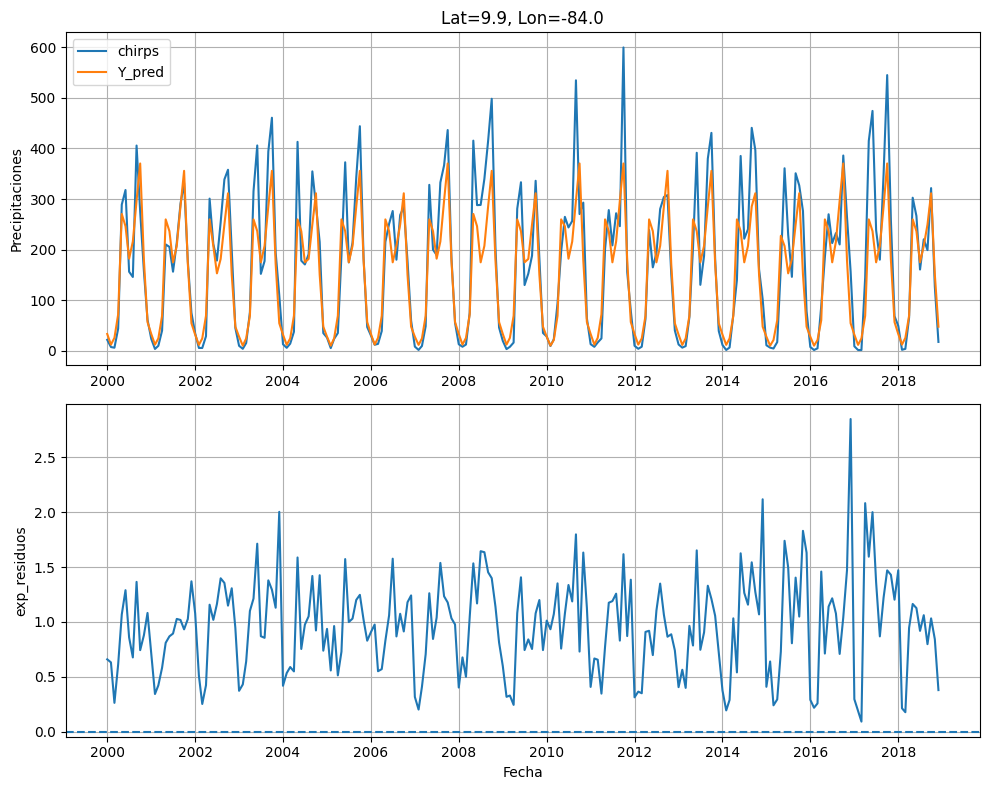

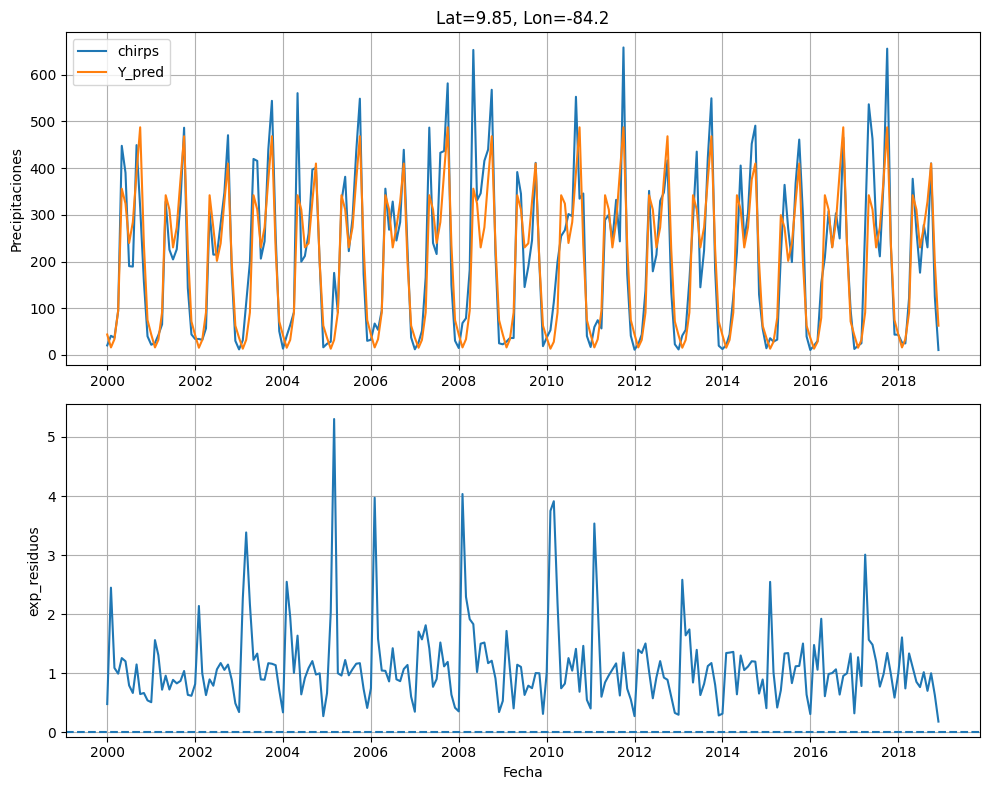

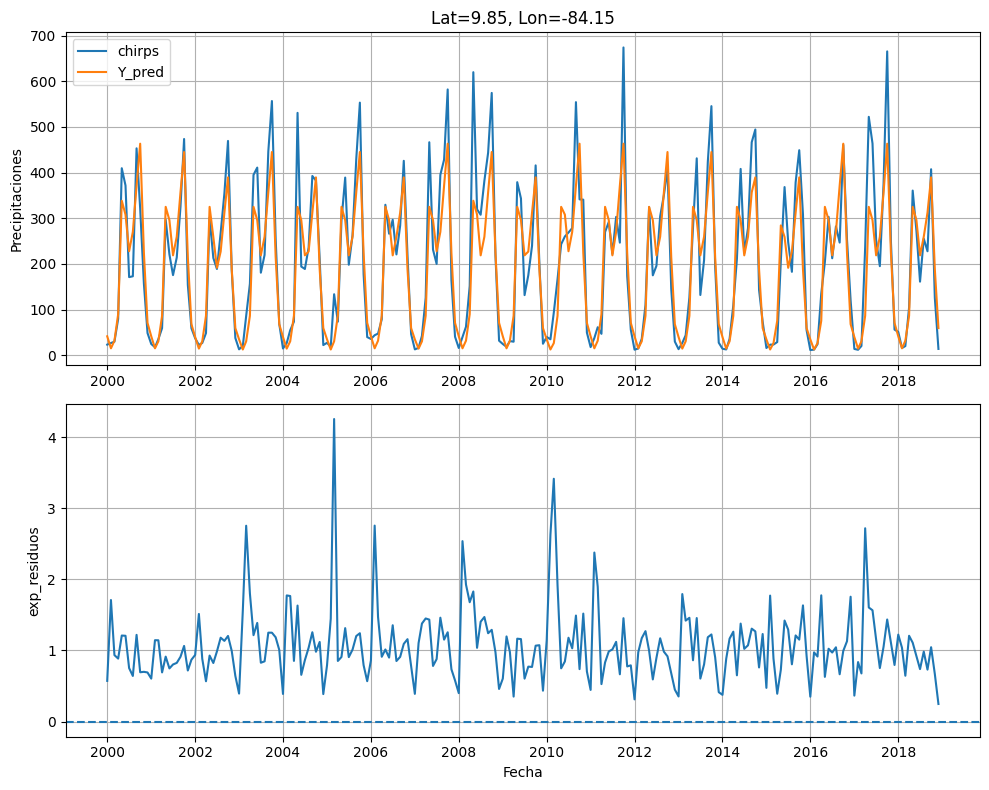

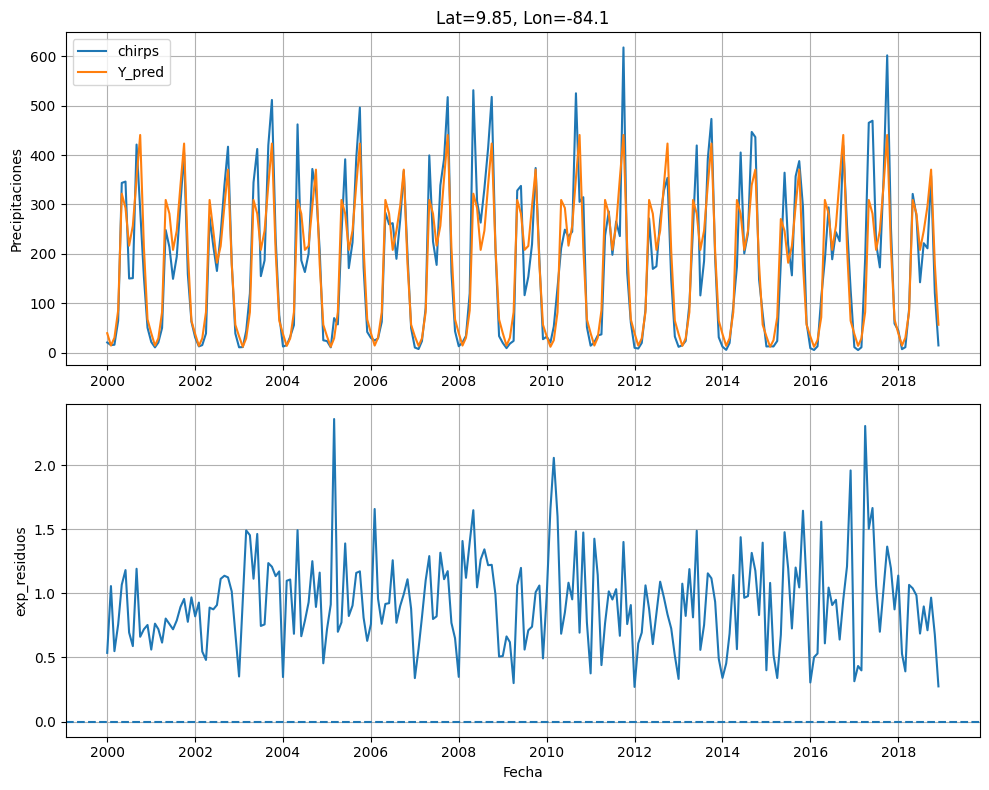

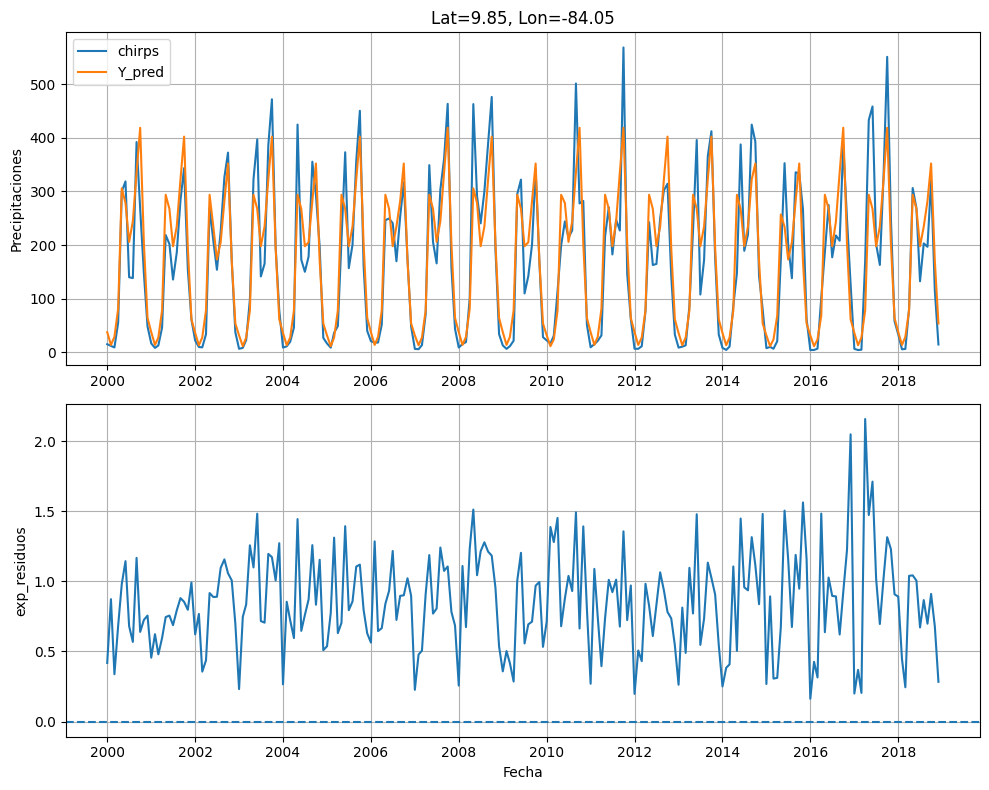

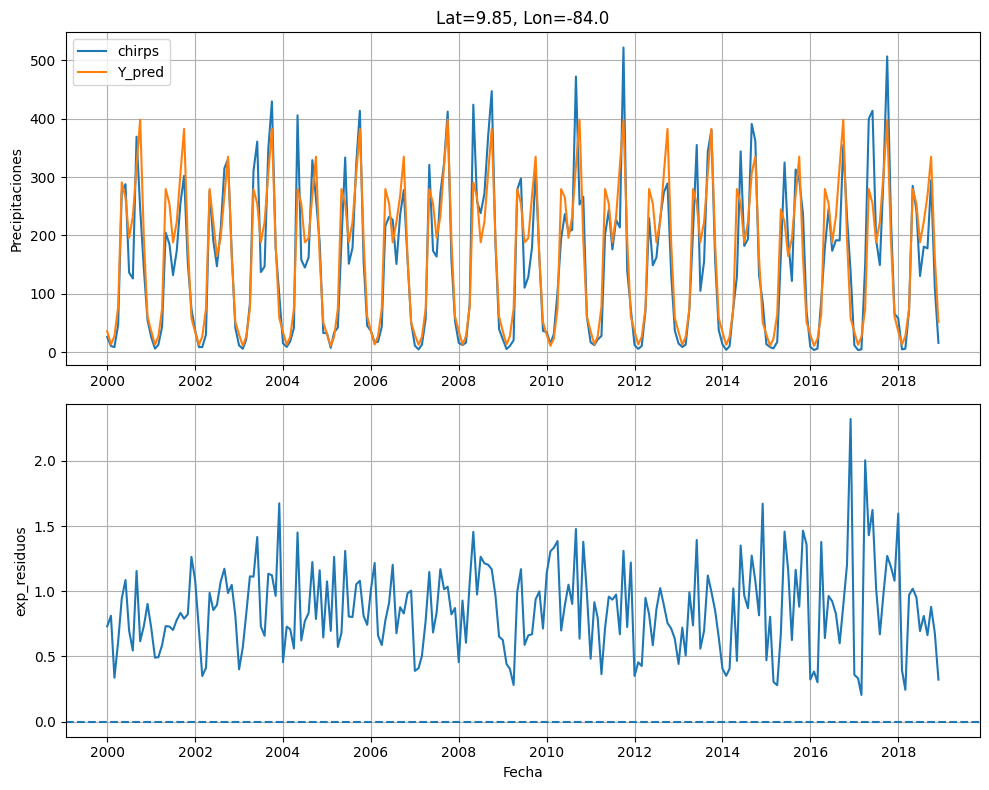

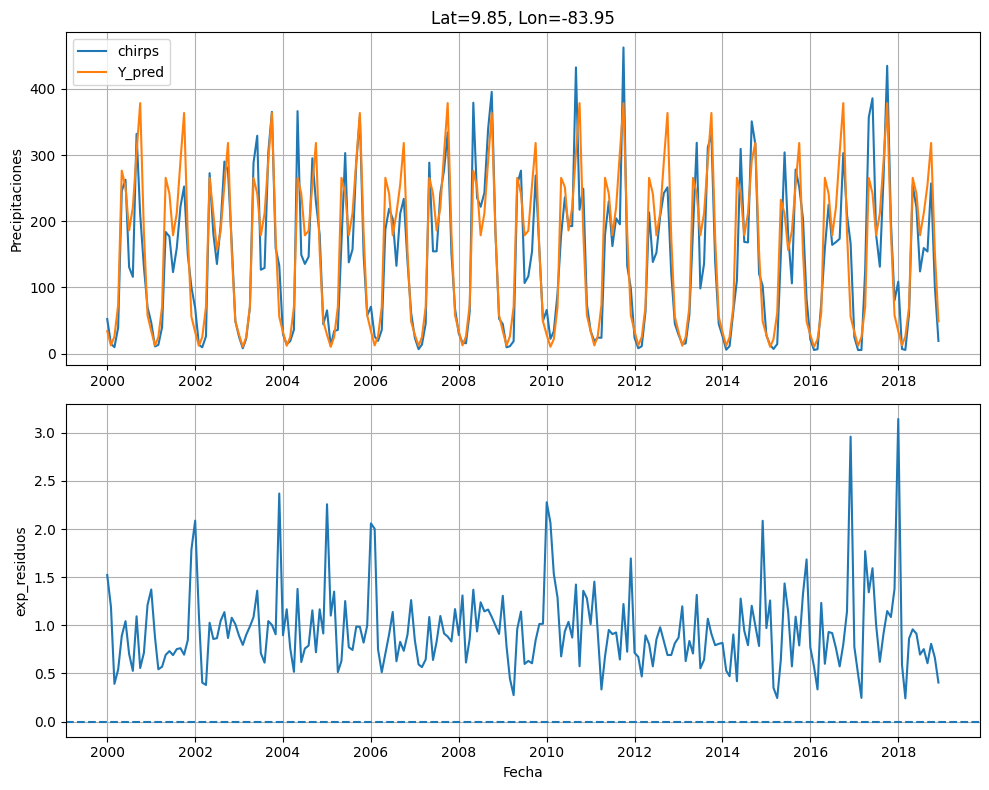

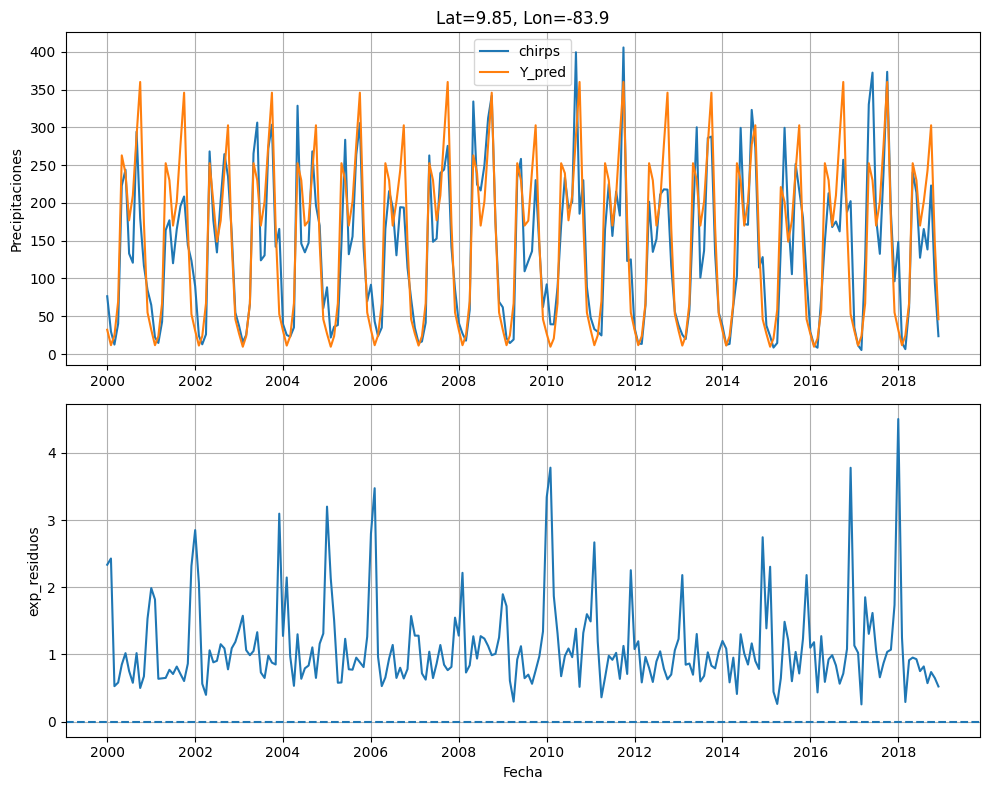

In [226]:
plot_modelo_glm_ubic(data['train'], data['ubic_training'])

In [228]:
data["train"]["exp_residuos"].mean(axis = 0)

1.0000000000000002

In [231]:
data["train"]

,lat,lon,year_month,chirps,elevation,date,month,year,sin_1,cos_1,sin_2,cos_2,ENSO,Y_plus,Y_pred,exp_residuos
13800,9.90,-84.10,2000-01,17.518916,1187.0,2000-01-01,1,2000,0.500,0.866,0.866,0.5,La Niña,18.518916,37.734467,0.490769
13801,9.90,-84.10,2000-02,7.998379,1187.0,2000-02-01,2,2000,0.866,0.500,0.866,-0.5,La Niña,8.998379,14.455007,0.622509
13802,9.90,-84.10,2000-03,11.473929,1187.0,2000-03-01,3,2000,1.000,0.000,0.000,-1.0,La Niña,12.473929,29.156876,0.427821
13803,9.90,-84.10,2000-04,52.564947,1187.0,2000-04-01,4,2000,0.866,-0.500,-0.866,-0.5,La Niña,53.564947,80.604789,0.664538
13804,9.90,-84.10,2000-05,306.690725,1187.0,2000-05-01,5,2000,0.500,-0.866,-0.866,0.5,La Niña,307.690725,300.135429,1.025173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
823,9.55,-83.85,2018-08,379.805167,1960.0,2018-08-01,8,2018,-0.866,-0.500,0.866,-0.5,Neutral,380.805167,297.816025,1.278659
824,9.55,-83.85,2018-09,308.292824,1960.0,2018-09-01,9,2018,-1.000,-0.000,0.000,-1.0,El Niño,309.292824,358.055386,0.863813
825,9.55,-83.85,2018-10,465.357867,1960.0,2018-10-01,10,2018,-0.866,0.500,-0.866,-0.5,El Niño,466.357867,446.370992,1.044776
826,9.55,-83.85,2018-11,218.433867,1960.0,2018-11-01,11,2018,-0.500,0.866,-0.866,0.5,El Niño,219.433867,216.400176,1.014019


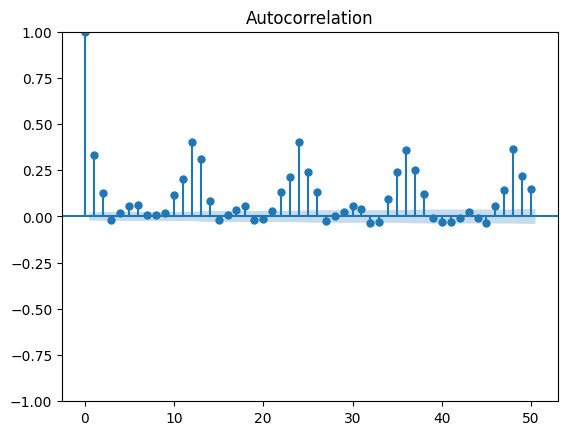

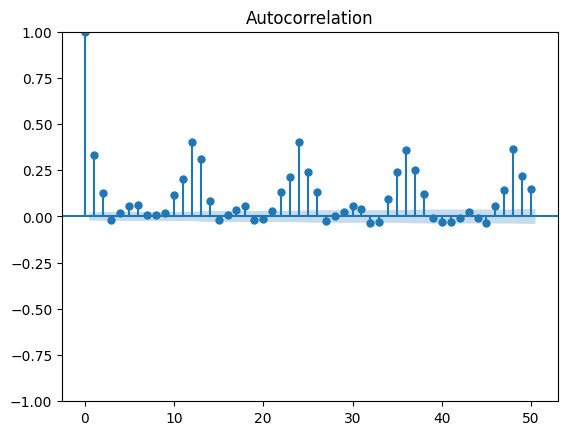

In [230]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(data["train"]["exp_residuos"], lags=50)